In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/data.csv")
model_df = df.copy()

In [3]:
model_df["TotalCharges"] = pd.to_numeric(
    model_df["TotalCharges"],
    errors="coerce"
)

In [4]:
model_df["TotalCharges"] = (
    model_df["TotalCharges"].fillna(0)
)

In [5]:
model_df = model_df.drop(
    columns=["customerID"]
)

In [6]:
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [7]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split( 
    X, 
    y, 
    test_size = 0.4,
    random_state = 42,
    stratify = y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp)

In [9]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4225, 19)
Validation: (1409, 19)
Test: (1409, 19)


In [10]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
    ]

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
    ]

In [11]:
X_train_categorical = X_train[categorical_features]
X_train_numerical = X_train[numerical_features]
X_val_categorical = X_val[categorical_features]
X_val_numerical = X_val[numerical_features]
X_test_categorical = X_test[categorical_features]
X_test_numerical = X_test[numerical_features]

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X_train_categorical.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
2833,Female,0,No,No,Yes,No,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Bank transfer (automatic)
846,Female,0,No,No,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)
2501,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check
6729,Male,0,Yes,Yes,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)
2903,Male,0,Yes,Yes,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Mailed check


In [13]:
encoder = OneHotEncoder(sparse_output =False, handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train_categorical)
X_val_encoded = encoder.transform(X_val_categorical)
X_test_encoded = encoder.transform(X_test_categorical)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numerical)
X_val_scaled = scaler.transform(X_val_numerical)
X_test_scaled = scaler.transform(X_test_numerical)

In [14]:
print("Original categorical:", X_train_categorical.shape)
print("Encoded categorical:", X_train_encoded.shape)

print("Original numerical:", X_train_numerical.shape)
print("Scaled numerical:", X_train_scaled.shape)

Original categorical: (4225, 16)
Encoded categorical: (4225, 43)
Original numerical: (4225, 3)
Scaled numerical: (4225, 3)


In [15]:
import numpy as np

X_train_prepared = np.hstack([
    X_train_encoded,
    X_train_scaled
])

X_val_prepared = np.hstack([
    X_val_encoded,
    X_val_scaled
])

X_test_prepared = np.hstack([
    X_test_encoded,
    X_test_scaled
])

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)

In [17]:
model.fit(X_train_prepared, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_val_pred = model.predict(X_val_prepared)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [20]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.8239886444286728
Precision: 0.6981132075471698
Recall: 0.5935828877005348
F1 Score: 0.6416184971098265
Confusion Matrix:
[[939  96]
 [152 222]]


for our first feature engineering experiment, lets test out customers who have fiber optic and month to month contract maybe be especiially likely to churn.

In [21]:
X_train_exp1 = X_train.copy()
X_val_exp1 = X_val.copy()
X_test_exp1 = X_test.copy()

In [22]:
X_train_exp1["Fiber_MonthToMonth"] = (
    (X_train_exp1["InternetService"] == "Fiber optic") &
    (X_train_exp1["Contract"] == "Month-to-month")
).astype(int)

In [23]:
X_val_exp1["Fiber_MonthToMonth"] = (
    (X_val_exp1["InternetService"] == "Fiber optic") &
    (X_val_exp1["Contract"] == "Month-to-month")
).astype(int)

X_test_exp1["Fiber_MonthToMonth"] = (
    (X_test_exp1["InternetService"] == "Fiber optic") &
    (X_test_exp1["Contract"] == "Month-to-month")
).astype(int)

In [24]:
X_train_exp1[
    ["InternetService", "Contract", "Fiber_MonthToMonth"]
].head(20)

,InternetService,Contract,Fiber_MonthToMonth
2833,DSL,Two year,0
846,DSL,Two year,0
2501,No,Two year,0
6729,DSL,Two year,0
2903,DSL,Month-to-month,0
5005,Fiber optic,One year,0
803,DSL,Two year,0
3096,DSL,Two year,0
6877,Fiber optic,Month-to-month,1
2078,DSL,One year,0


In [25]:
numerical_columns_exp1 = numerical_features + [
    "Fiber_MonthToMonth"
]

In [26]:
X_train_cat_exp1 = X_train_exp1[categorical_features]
X_val_cat_exp1 = X_val_exp1[categorical_features]
X_test_cat_exp1 = X_test_exp1[categorical_features]

X_train_num_exp1 = X_train_exp1[numerical_columns_exp1]
X_val_num_exp1 = X_val_exp1[numerical_columns_exp1]
X_test_num_exp1 = X_test_exp1[numerical_columns_exp1]

In [27]:
encoder_exp1 = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

scaler_exp1 = StandardScaler()

In [28]:
X_train_encoded_exp1 = encoder_exp1.fit_transform(
    X_train_cat_exp1
)

X_val_encoded_exp1 = encoder_exp1.transform(
    X_val_cat_exp1
)

X_test_encoded_exp1 = encoder_exp1.transform(
    X_test_cat_exp1
)

In [29]:
X_train_scaled_exp1 = scaler_exp1.fit_transform(
    X_train_num_exp1
)

X_val_scaled_exp1 = scaler_exp1.transform(
    X_val_num_exp1
)

X_test_scaled_exp1 = scaler_exp1.transform(
    X_test_num_exp1
)

In [30]:
X_train_prepared_exp1 = np.hstack([
    X_train_encoded_exp1,
    X_train_scaled_exp1
])

X_val_prepared_exp1 = np.hstack([
    X_val_encoded_exp1,
    X_val_scaled_exp1
])

X_test_prepared_exp1 = np.hstack([
    X_test_encoded_exp1,
    X_test_scaled_exp1
])

In [31]:
model_exp1 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_exp1.fit(
    X_train_prepared_exp1,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
y_val_pred_exp1 = model_exp1.predict(
    X_val_prepared_exp1
)

In [33]:
accuracy_exp1 = accuracy_score(
    y_val,
    y_val_pred_exp1
)

precision_exp1 = precision_score(
    y_val,
    y_val_pred_exp1
)

recall_exp1 = recall_score(
    y_val,
    y_val_pred_exp1
)

f1_exp1 = f1_score(
    y_val,
    y_val_pred_exp1
)

print("Accuracy:", accuracy_exp1)
print("Precision:", precision_exp1)
print("Recall:", recall_exp1)
print("F1:", f1_exp1)

print(
    confusion_matrix(
        y_val,
        y_val_pred_exp1
    )
)

Accuracy: 0.8239886444286728
Precision: 0.6981132075471698
Recall: 0.5935828877005348
F1: 0.6416184971098265
[[939  96]
 [152 222]]


lets create an experiment function so we can optimize this process

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [35]:
def run_experiment(
    X_train,
    X_val,
    y_train,
    y_val,
    categorical_columns,
    numerical_columns
):

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_columns
            ),

            (
                "numerical",
                StandardScaler(),
                numerical_columns
            )
        ]
    )

    # Preprocessing + model
    pipeline = Pipeline([
        ("preprocessor", preprocessor),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Predict
    y_pred = pipeline.predict(
        X_val
    )

    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

    return pipeline

In [36]:
X_train_exp = X_train.copy()
X_val_exp = X_val.copy()

In [37]:
X_train_exp["AutomaticPayment"] = (
    X_train_exp["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ])
).astype(int)

X_val_exp["AutomaticPayment"] = (
    X_val_exp["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ])
).astype(int)

In [38]:
numerical_features_exp = (
    numerical_features
    + ["AutomaticPayment"]
)

In [39]:
automatic_payment_model = run_experiment(
    X_train_exp,
    X_val_exp,
    y_train,
    y_val,
    categorical_features,
    numerical_features_exp
)

Accuracy: 0.8232789212207239
Precision: 0.6971608832807571
Recall: 0.5909090909090909
F1: 0.6396526772793053

Confusion Matrix:
[[939  96]
 [153 221]]


In [41]:
import matplotlib.pyplot as plt

tenure_group
(-0.001, 6.0]    0.529372
(6.0, 12.0]      0.358865
(12.0, 24.0]     0.287109
(24.0, 36.0]     0.216346
(36.0, 48.0]     0.190289
(48.0, 60.0]     0.144231
(60.0, 72.0]     0.066098
Name: Churn, dtype: float64


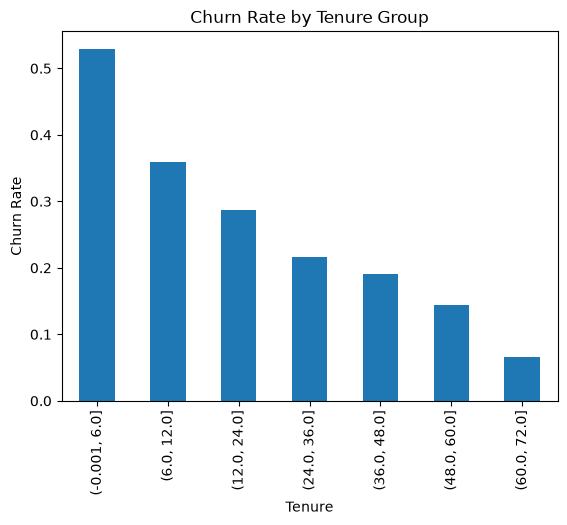

In [42]:
tenure_analysis = model_df.copy()

tenure_analysis["tenure_group"] = pd.cut(
    tenure_analysis["tenure"],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    include_lowest=True
)

tenure_churn = (
    tenure_analysis
    .groupby("tenure_group", observed=True)["Churn"]
    .mean()
)

print(tenure_churn)

tenure_churn.plot(kind="bar")

plt.ylabel("Churn Rate")
plt.xlabel("Tenure")
plt.title("Churn Rate by Tenure Group")
plt.show()

In [51]:
X_train_exp = X_train.copy()
X_val_exp = X_val.copy()

In [52]:
X_train_exp["tenure_squared"] = X_train_exp["tenure"] ** 2
X_val_exp["tenure_squared"] = X_val_exp["tenure"] ** 2

In [53]:
numerical_features_exp = (
    numerical_features
    + ["tenure_squared"]
)

In [54]:
run_experiment(
    X_train_exp,
    X_val_exp,
    y_train,
    y_val,
    categorical_features,
    numerical_features_exp
)

Accuracy: 0.8246983676366217
Precision: 0.7138047138047138
Recall: 0.5668449197860963
F1: 0.6318926974664679

Confusion Matrix:
[[950  85]
 [162 212]]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'tenure_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [57]:
from sklearn.inspection import permutation_importance
import pandas as pd

baseline_pipeline = run_experiment(
    X_train,
    X_val,
    y_train,
    y_val,
    categorical_features,
    numerical_features
)

result = permutation_importance(
    baseline_pipeline,
    X_val,
    y_val,
    scoring="f1",
    n_repeats=20,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

Accuracy: 0.8239886444286728
Precision: 0.6981132075471698
Recall: 0.5935828877005348
F1: 0.6416184971098265

Confusion Matrix:
[[939  96]
 [152 222]]
             feature  importance
4             tenure    0.261896
14          Contract    0.142479
7    InternetService    0.117310
16     PaymentMethod    0.043669
11       TechSupport    0.039952
8     OnlineSecurity    0.037885
15  PaperlessBilling    0.035301
17    MonthlyCharges    0.026683
18      TotalCharges    0.026602
6      MultipleLines    0.025776
12       StreamingTV    0.019222
9       OnlineBackup    0.018485
3         Dependents    0.017083
10  DeviceProtection    0.011481
1      SeniorCitizen    0.008017
13   StreamingMovies    0.006893
5       PhoneService    0.006182
0             gender    0.001685
2            Partner    0.000885


In [58]:
strong_features = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "InternetService",
    "PaymentMethod"
]

medium_features = [
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling",
    "MonthlyCharges",
    "TotalCharges",
    "MultipleLines",
    "StreamingTV",
]

weak_features = [
    "SeniorCitizen",
    "Partner",  
    "gender",
    "Dependents",
    "PhoneService",
    "DeviceProtection",
    "OnlineBackup",
]

In [59]:
X_train_no_weak = X_train.drop(
    columns=weak_features
)

X_val_no_weak = X_val.drop(
    columns=weak_features
)

In [60]:
categorical_features_no_weak = [
    feature
    for feature in categorical_features
    if feature not in weak_features
]

numerical_features_no_weak = [
    feature
    for feature in numerical_features
    if feature not in weak_features
]

In [61]:
model_no_weak = run_experiment(
    X_train_no_weak,
    X_val_no_weak,
    y_train,
    y_val,
    categorical_features_no_weak,
    numerical_features_no_weak
)

Accuracy: 0.8147622427253371
Precision: 0.677115987460815
Recall: 0.5775401069518716
F1: 0.6233766233766234

Confusion Matrix:
[[932 103]
 [158 216]]


In [62]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train_prepared,
    y_train
)

y_train_pred_tree = tree_model.predict(
    X_train_prepared
)

y_val_pred_tree = tree_model.predict(
    X_val_prepared
)

In [63]:
print("TRAIN")

print("Accuracy:", accuracy_score(y_train, y_train_pred_tree))
print("Precision:", precision_score(y_train, y_train_pred_tree))
print("Recall:", recall_score(y_train, y_train_pred_tree))
print("F1:", f1_score(y_train, y_train_pred_tree))

print("\nVALIDATION")

print("Accuracy:", accuracy_score(y_val, y_val_pred_tree))
print("Precision:", precision_score(y_val, y_val_pred_tree))
print("Recall:", recall_score(y_val, y_val_pred_tree))
print("F1:", f1_score(y_val, y_val_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_tree))

TRAIN
Accuracy: 0.9983431952662722
Precision: 1.0
Recall: 0.9937555753791257
F1: 0.9968680089485459

VALIDATION
Accuracy: 0.7359829666430092
Precision: 0.5025125628140703
Recall: 0.5347593582887701
F1: 0.5181347150259067

Confusion Matrix:
[[837 198]
 [174 200]]


In [64]:
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Tree depth: 22
Number of leaves: 798


In [65]:
depths = [3, 5, 7, 10, 15]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_prepared, y_train)

    train_pred = model.predict(X_train_prepared)
    val_pred = model.predict(X_val_prepared)

    print("Depth:", depth)
    print("Train F1:", f1_score(y_train, train_pred))
    print("Val F1:", f1_score(y_val, val_pred))
    print("--------------------")

Depth: 3
Train F1: 0.48620082207868465
Val F1: 0.45045045045045046
--------------------
Depth: 5
Train F1: 0.6227544910179641
Val F1: 0.5883977900552486
--------------------
Depth: 7
Train F1: 0.6796657381615598
Val F1: 0.5772357723577236
--------------------
Depth: 10
Train F1: 0.7913938260056127
Val F1: 0.5527777777777778
--------------------
Depth: 15
Train F1: 0.9695613249776186
Val F1: 0.5319426336375489
--------------------


In [66]:
depths = [4, 5, 6, 7, 8]

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_prepared, y_train)

    train_pred = model.predict(X_train_prepared)
    val_pred = model.predict(X_val_prepared)

    print("Depth:", depth)
    print("Train F1:", f1_score(y_train, train_pred))
    print("Val F1:", f1_score(y_val, val_pred))
    print("----------------")

Depth: 4
Train F1: 0.5484383271572261
Val F1: 0.5258064516129032
----------------
Depth: 5
Train F1: 0.6227544910179641
Val F1: 0.5883977900552486
----------------
Depth: 6
Train F1: 0.6264705882352941
Val F1: 0.5655375552282769
----------------
Depth: 7
Train F1: 0.6796657381615598
Val F1: 0.5772357723577236
----------------
Depth: 8
Train F1: 0.7001434720229556
Val F1: 0.5441595441595442
----------------


In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [68]:
rf_model.fit(
    X_train_prepared,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [69]:
y_train_pred_rf = rf_model.predict(
    X_train_prepared
)

y_val_pred_rf = rf_model.predict(
    X_val_prepared
)

In [70]:
print("TRAIN")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Precision:", precision_score(y_train, y_train_pred_rf))
print("Recall:", recall_score(y_train, y_train_pred_rf))
print("F1:", f1_score(y_train, y_train_pred_rf))

print("\nVALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall:", recall_score(y_val, y_val_pred_rf))
print("F1:", f1_score(y_val, y_val_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

TRAIN
Accuracy: 0.9983431952662722
Precision: 0.9973214285714286
Recall: 0.9964317573595004
F1: 0.9968763944667559

VALIDATION
Accuracy: 0.7970191625266146
Precision: 0.658273381294964
Recall: 0.4893048128342246
F1: 0.5613496932515337

Confusion Matrix:
[[940  95]
 [191 183]]


In [71]:
depths = [3, 5, 7, 10, 15, None]

for depth in depths:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_prepared, y_train)

    train_pred = rf.predict(X_train_prepared)
    val_pred = rf.predict(X_val_prepared)

    print("Depth:", depth)
    print("Train F1:", f1_score(y_train, train_pred))
    print("Val F1:", f1_score(y_val, val_pred))
    print("--------------------")

Depth: 3
Train F1: 0.44695543000627747
Val F1: 0.4346153846153846
--------------------
Depth: 5
Train F1: 0.5382467895030709
Val F1: 0.5110732538330494
--------------------
Depth: 7
Train F1: 0.6295149638802889
Val F1: 0.5585874799357945
--------------------
Depth: 10
Train F1: 0.7685631629701061
Val F1: 0.5848484848484848
--------------------
Depth: 15
Train F1: 0.9849290780141844
Val F1: 0.5705614567526556
--------------------
Depth: None
Train F1: 0.9968763944667559
Val F1: 0.5613496932515337
--------------------


Logistic regression is the best model. lets tune it.

### Classification Threshold Experiment

The default Logistic Regression threshold is 0.50.

For customer churn, false negatives can be especially costly:
a false negative means the model predicts that a customer will stay,
but the customer actually churns.

A false positive may be less costly because it only means that a loyal
customer is incorrectly flagged as at risk and may receive an unnecessary
retention action.

Therefore, we will experiment with lowering the classification threshold.
This should increase recall (catch more actual churners), but will usually
reduce precision (create more false alarms).

The goal is not simply to maximize accuracy, but to find an appropriate
precision-recall tradeoff for the business problem.

In [72]:
y_val_prob = baseline_pipeline.predict_proba(X_val)[:, 1]

In [73]:
threshold = 0.40

y_val_pred_threshold = (
    y_val_prob >= threshold
).astype(int)

In [74]:
accuracy = accuracy_score(
    y_val,
    y_val_pred_threshold
)

precision = precision_score(
    y_val,
    y_val_pred_threshold
)

recall = recall_score(
    y_val,
    y_val_pred_threshold
)

f1 = f1_score(
    y_val,
    y_val_pred_threshold
)

print("Threshold:", threshold)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred_threshold
    )
)

Threshold: 0.4
Accuracy: 0.7934705464868701
Precision: 0.5936794582392777
Recall: 0.7032085561497327
F1: 0.6438188494492044

Confusion Matrix:
[[855 180]
 [111 263]]


In [75]:
thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55
]

for threshold in thresholds:

    predictions = (
        y_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions
    )

    recall = recall_score(
        y_val,
        predictions
    )

    f1 = f1_score(
        y_val,
        predictions
    )

    print("Threshold:", threshold)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("--------------------")

Threshold: 0.3
Precision: 0.5342960288808665
Recall: 0.7914438502673797
F1: 0.6379310344827587
--------------------
Threshold: 0.35
Precision: 0.5673469387755102
Recall: 0.7433155080213903
F1: 0.6435185185185185
--------------------
Threshold: 0.4
Precision: 0.5936794582392777
Recall: 0.7032085561497327
F1: 0.6438188494492044
--------------------
Threshold: 0.45
Precision: 0.6302083333333334
Recall: 0.6470588235294118
F1: 0.6385224274406333
--------------------
Threshold: 0.5
Precision: 0.6981132075471698
Recall: 0.5935828877005348
F1: 0.6416184971098265
--------------------
Threshold: 0.55
Precision: 0.7209302325581395
Recall: 0.49732620320855614
F1: 0.5886075949367089
--------------------


### Selected Classification Threshold: 0.35

A threshold of 0.35 was selected instead of the default 0.50.

Thresholds of 0.35 and 0.40 produced almost identical F1 scores,
but 0.35 achieved substantially higher recall (74.3% vs 70.3%).

For customer churn prediction, false negatives are considered more costly
than false positives because failing to identify a customer who actually
churns may result in losing that customer entirely.

Therefore, the model accepts additional false positives in exchange for
identifying more customers who are genuinely at risk of churn.

In [79]:
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

balanced_model.fit(
    X_train_prepared,
    y_train
)

y_val_prob_balanced = balanced_model.predict_proba(
    X_val_prepared
)[:, 1]

threshold = 0.50

y_val_pred_balanced = (
    y_val_prob_balanced >= threshold
).astype(int)

In [80]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_balanced))
print("Precision:", precision_score(y_val, y_val_pred_balanced))
print("Recall:", recall_score(y_val, y_val_pred_balanced))
print("F1:", f1_score(y_val, y_val_pred_balanced))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred_balanced
    )
)

Accuracy: 0.7494677075940384
Precision: 0.5176470588235295
Recall: 0.8235294117647058
F1: 0.6357069143446853

Confusion Matrix:
[[748 287]
 [ 66 308]]


Ill just stick with the threshold of 0.35

In [81]:
y_test_prob = model.predict_proba(
    X_test_prepared
)[:, 1]

In [82]:
threshold = 0.35

y_test_pred = (
    y_test_prob >= threshold
).astype(int)

In [83]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

print("FINAL TEST RESULTS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)

FINAL TEST RESULTS
Accuracy: 0.7452093683463449
Precision: 0.5177304964539007
Recall: 0.5855614973262032
F1: 0.5495608531994981

Confusion Matrix:
[[831 204]
 [155 219]]


## IMPORTANT NOTE
Its a surprise to see the test results to be different from the cross val
so we'll try to do stratified K fold splitting, and thats fine since we're using logistic regression, computation isnt so high

In [84]:
import pandas as pd

X_dev = pd.concat([
    X_train,
    X_val
])

y_dev = pd.concat([
    y_train,
    y_val
])

In [85]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [86]:
for fold, (train_index, val_index) in enumerate(
    skf.split(X_dev, y_dev),
    start=1
):

    print("Fold:", fold)
    print("Training customers:", len(train_index))
    print("Validation customers:", len(val_index))
    print("-------------------")

Fold: 1
Training customers: 4507
Validation customers: 1127
-------------------
Fold: 2
Training customers: 4507
Validation customers: 1127
-------------------
Fold: 3
Training customers: 4507
Validation customers: 1127
-------------------
Fold: 4
Training customers: 4507
Validation customers: 1127
-------------------
Fold: 5
Training customers: 4508
Validation customers: 1126
-------------------


In [87]:
from sklearn.model_selection import cross_validate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [88]:
cv_results = cross_validate(
    baseline_pipeline,
    X_dev,
    y_dev,
    cv=skf,
    scoring=scoring
)

In [89]:
print("Accuracy:", cv_results["test_accuracy"])
print("Precision:", cv_results["test_precision"])
print("Recall:", cv_results["test_recall"])
print("F1:", cv_results["test_f1"])

Accuracy: [0.82431233 0.80745342 0.80301686 0.79503106 0.79928952]
Precision: [0.69803922 0.66269841 0.64750958 0.61971831 0.66666667]
Recall: [0.59531773 0.55852843 0.56521739 0.58862876 0.48829431]
F1: [0.64259928 0.6061706  0.60357143 0.60377358 0.56370656]


In [90]:
import numpy as np

print(
    "Mean Accuracy:",
    np.mean(cv_results["test_accuracy"])
)

print(
    "Mean Precision:",
    np.mean(cv_results["test_precision"])
)

print(
    "Mean Recall:",
    np.mean(cv_results["test_recall"])
)

print(
    "Mean F1:",
    np.mean(cv_results["test_f1"])
)

Mean Accuracy: 0.8058206370045122
Mean Precision: 0.658926436690914
Mean Recall: 0.5591973244147157
Mean F1: 0.6039642908146126


In [92]:
from sklearn.model_selection import cross_val_predict
oof_probabilities = cross_val_predict(
    baseline_pipeline,
    X_dev,
    y_dev,
    cv=skf,
    method="predict_proba"
)[:, 1]

In [93]:
thresholds = [
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

for threshold in thresholds:

    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_dev,
        predictions
    )

    recall = recall_score(
        y_dev,
        predictions
    )

    f1 = f1_score(
        y_dev,
        predictions
    )

    print("Threshold:", threshold)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("--------------------")

Threshold: 0.25
Precision: 0.5043442283822921
Recall: 0.8153846153846154
F1: 0.6232106339468303
--------------------
Threshold: 0.3
Precision: 0.536150234741784
Recall: 0.7638795986622073
F1: 0.6300689655172413
--------------------
Threshold: 0.35
Precision: 0.5643879173290938
Recall: 0.7123745819397993
F1: 0.6298048492016558
--------------------
Threshold: 0.4
Precision: 0.5917759237187128
Recall: 0.6642140468227424
F1: 0.6259060825716987
--------------------
Threshold: 0.45
Precision: 0.6265389876880985
Recall: 0.6127090301003344
F1: 0.6195468380114981
--------------------
Threshold: 0.5
Precision: 0.6577498033044846
Recall: 0.5591973244147157
F1: 0.6044830079537238
--------------------


In [94]:
final_model = baseline_pipeline

final_model.fit(
    X_dev,
    y_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [96]:
y_test_prob_final = final_model.predict_proba(
    X_test
)[:, 1]

final_threshold = 0.30

y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_test_pred_final))
print("Precision:", precision_score(y_test, y_test_pred_final))
print("Recall:", recall_score(y_test, y_test_pred_final))
print("F1:", f1_score(y_test, y_test_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

Accuracy: 0.7572746628814763
Precision: 0.5293040293040293
Recall: 0.7727272727272727
F1: 0.6282608695652174

Confusion Matrix:
[[778 257]
 [ 85 289]]


In [98]:
import joblib

joblib.dump(
    final_model,
    "../models/churn_logistic_model.joblib"
)

['../models/churn_logistic_model.joblib']

In [99]:
import json

model_metadata = {
    "threshold": 0.30,
    "model_type": "Logistic Regression",
    "target": "Churn",
    "positive_class": 1
}

with open(
    "../models/model_metadata.json",
    "w"
) as f:
    json.dump(model_metadata, f, indent=4)